# Project Overview: Wine Quality
**Objective:** To predict discrete wine quality ratings based on physicochemical features, focusing on maximizing the Quadratic Weighted Kappa (QWK) metric through robust regression and optimized threshold post-processing.

## 1. Libraries & Workspace Setup

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s3e5')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s3e5


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import cohen_kappa_score
from scipy.optimize import minimize
import joblib
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [4]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e5/train.csv')
test_df=pd.read_csv('//kaggle/input/competitions/playground-series-s3e5/test.csv')

In [5]:
train_df.head()

,Id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,8.0,0.50,0.39,2.2,0.073,30.0,39.0,0.99572,3.33,0.77,12.1,6
1,1,9.3,0.30,0.73,2.3,0.092,30.0,67.0,0.99854,3.32,0.67,12.8,6
2,2,7.1,0.51,0.03,2.1,0.059,3.0,12.0,0.99660,3.52,0.73,11.3,7
3,3,8.1,0.87,0.22,2.6,0.084,11.0,65.0,0.99730,3.20,0.53,9.8,5
4,4,8.5,0.36,0.30,2.3,0.079,10.0,45.0,0.99444,3.20,1.36,9.5,6


In [6]:
test_df.head()

,Id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,2056,7.2,0.510,0.01,2.0,0.077,31.0,54.0,0.99748,3.39,0.59,9.8
1,2057,7.2,0.755,0.15,2.0,0.102,14.0,35.0,0.99586,3.33,0.68,10.0
2,2058,8.4,0.460,0.40,2.0,0.065,21.0,50.0,0.99774,3.08,0.65,9.5
3,2059,8.0,0.470,0.40,1.8,0.056,14.0,25.0,0.99480,3.30,0.65,11.7
4,2060,6.5,0.340,0.32,2.1,0.044,8.0,94.0,0.99356,3.23,0.48,12.8


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2056 entries, 0 to 2055
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    2056 non-null   int64  
 1   fixed acidity         2056 non-null   float64
 2   volatile acidity      2056 non-null   float64
 3   citric acid           2056 non-null   float64
 4   residual sugar        2056 non-null   float64
 5   chlorides             2056 non-null   float64
 6   free sulfur dioxide   2056 non-null   float64
 7   total sulfur dioxide  2056 non-null   float64
 8   density               2056 non-null   float64
 9   pH                    2056 non-null   float64
 10  sulphates             2056 non-null   float64
 11  alcohol               2056 non-null   float64
 12  quality               2056 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 208.9 KB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    1372 non-null   int64  
 1   fixed acidity         1372 non-null   float64
 2   volatile acidity      1372 non-null   float64
 3   citric acid           1372 non-null   float64
 4   residual sugar        1372 non-null   float64
 5   chlorides             1372 non-null   float64
 6   free sulfur dioxide   1372 non-null   float64
 7   total sulfur dioxide  1372 non-null   float64
 8   density               1372 non-null   float64
 9   pH                    1372 non-null   float64
 10  sulphates             1372 non-null   float64
 11  alcohol               1372 non-null   float64
dtypes: float64(11), int64(1)
memory usage: 128.8 KB


In [9]:
train_df.shape

(2056, 13)

In [10]:
test_df.shape

(1372, 12)

In [11]:
train_df.isnull().sum()

Id                      0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [12]:
test_df.isnull().sum()

Id                      0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

## 3. Exploratory Data Analysis

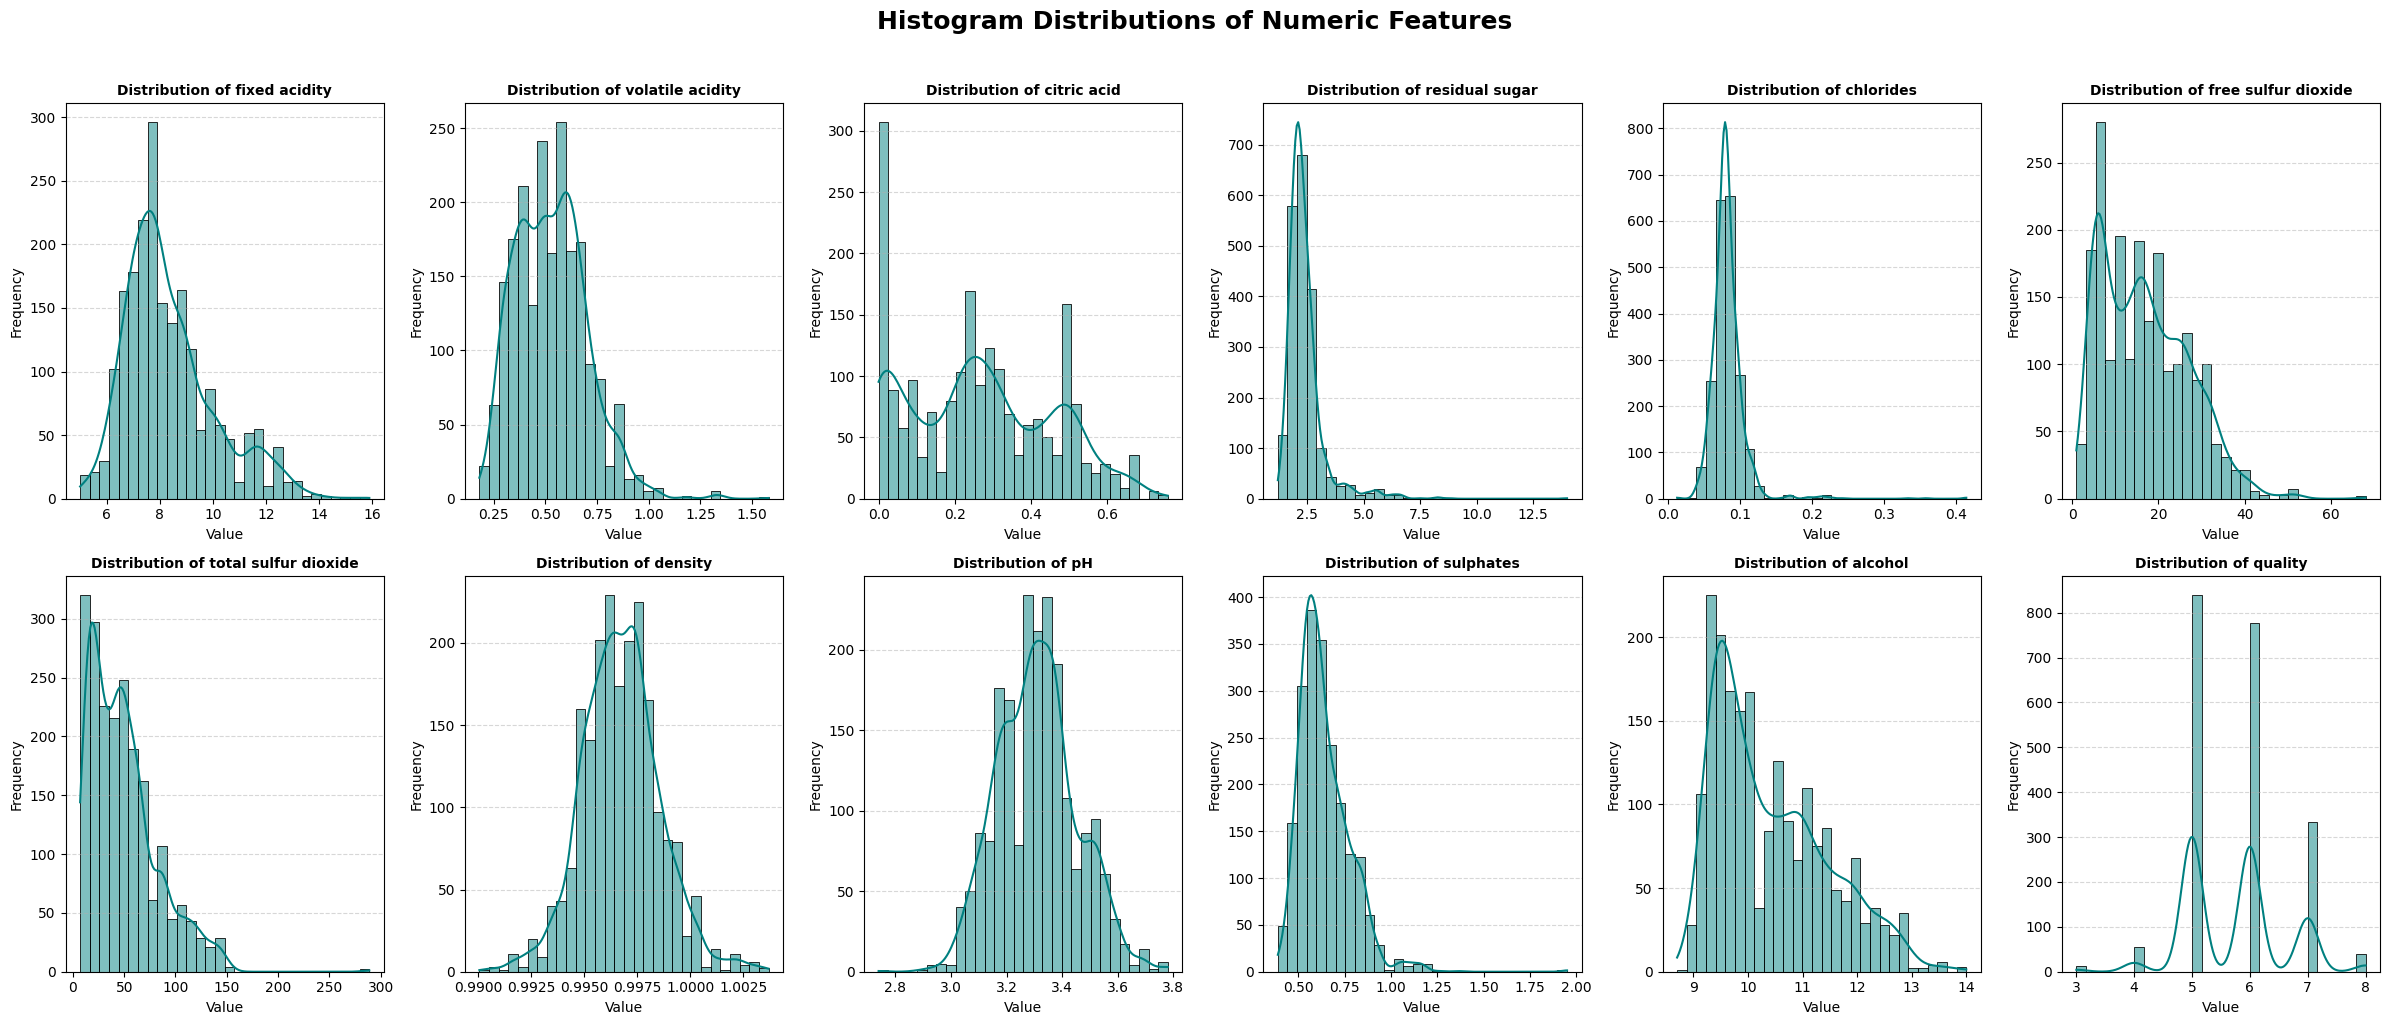

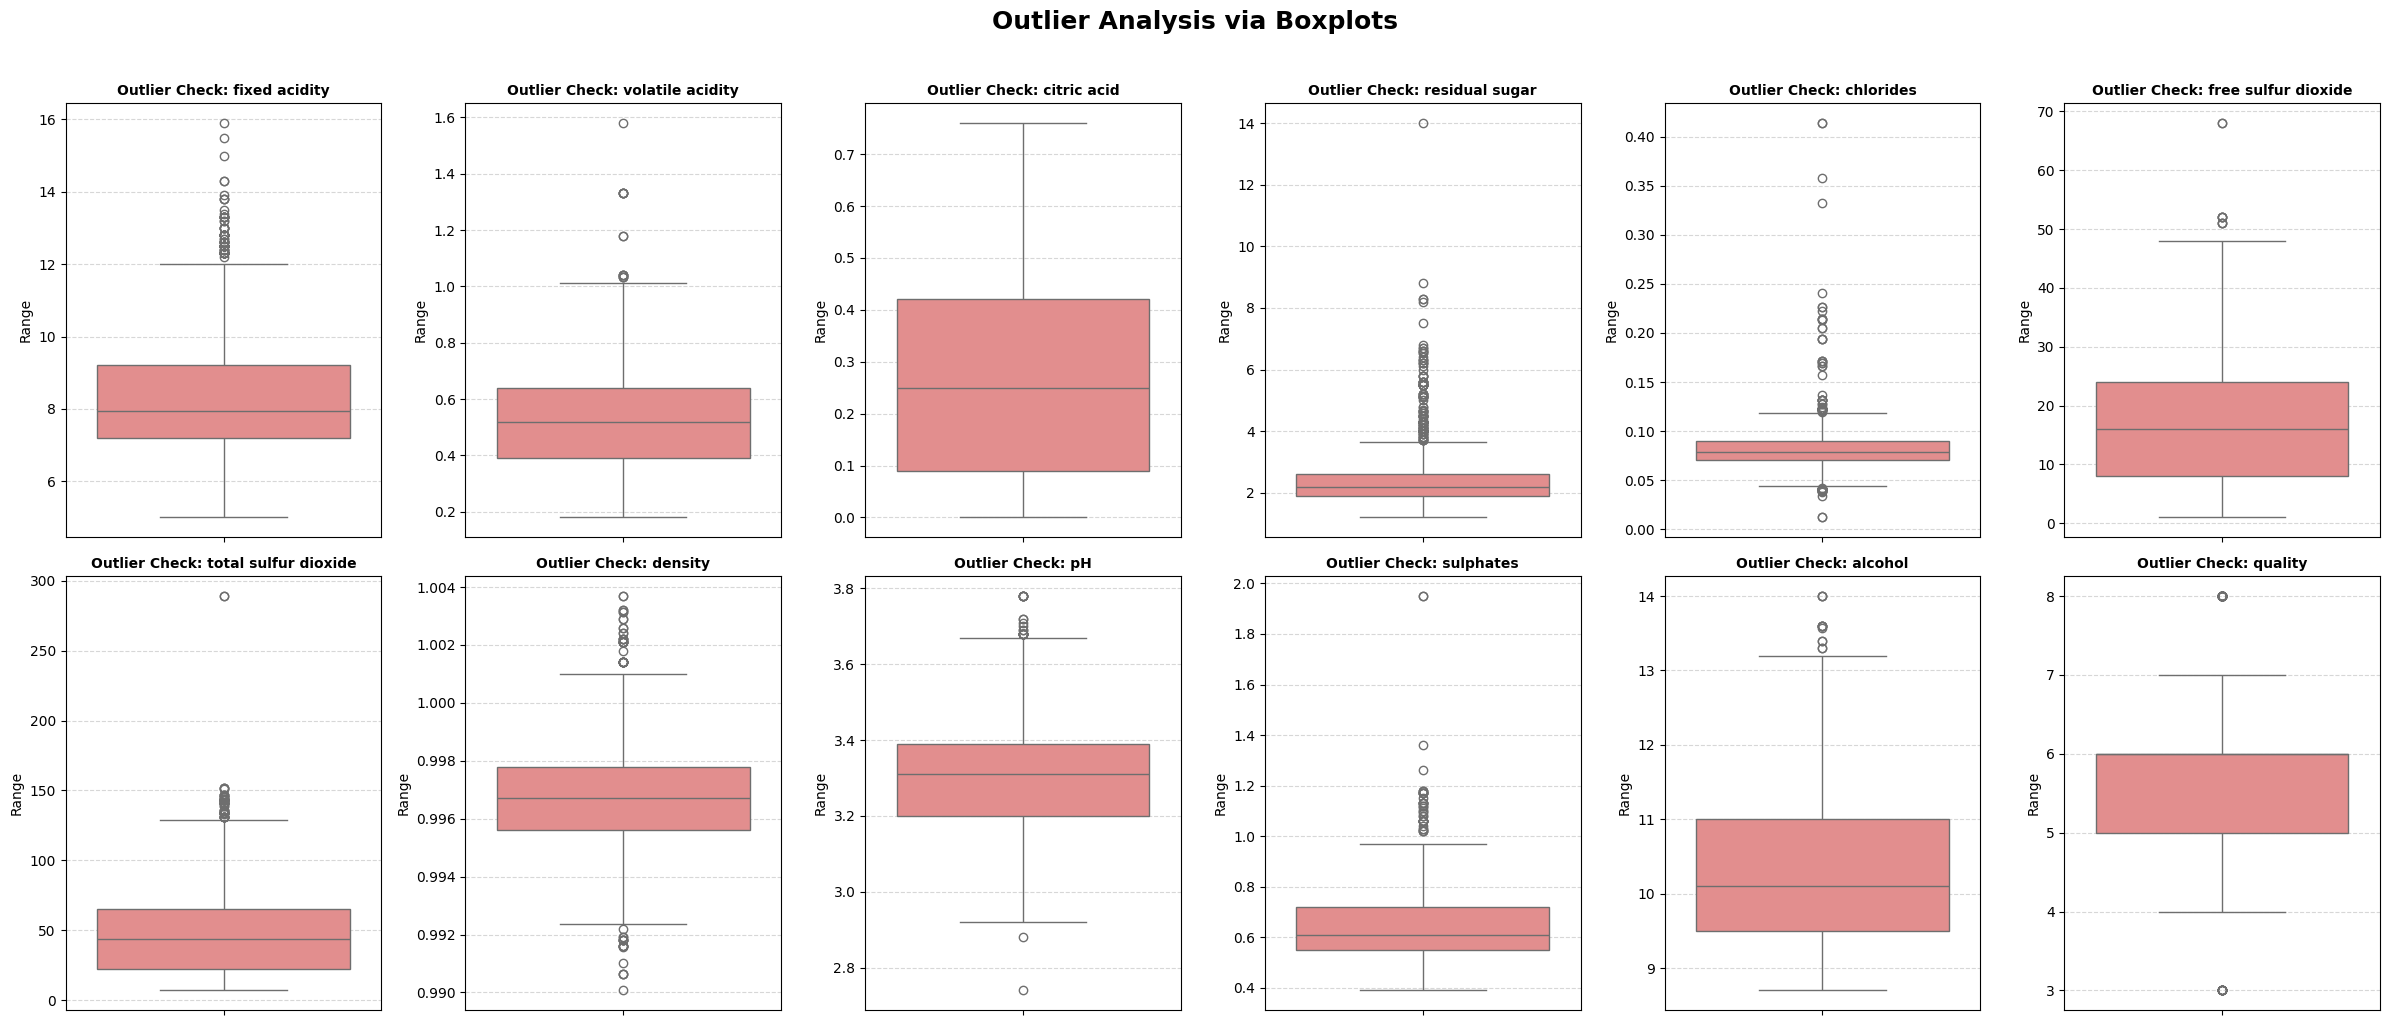

In [13]:
num_features = list(train_df.drop(columns=['Id']).columns)

# Histogram
fig, axes = plt.subplots(2, 6, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(2, 6, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

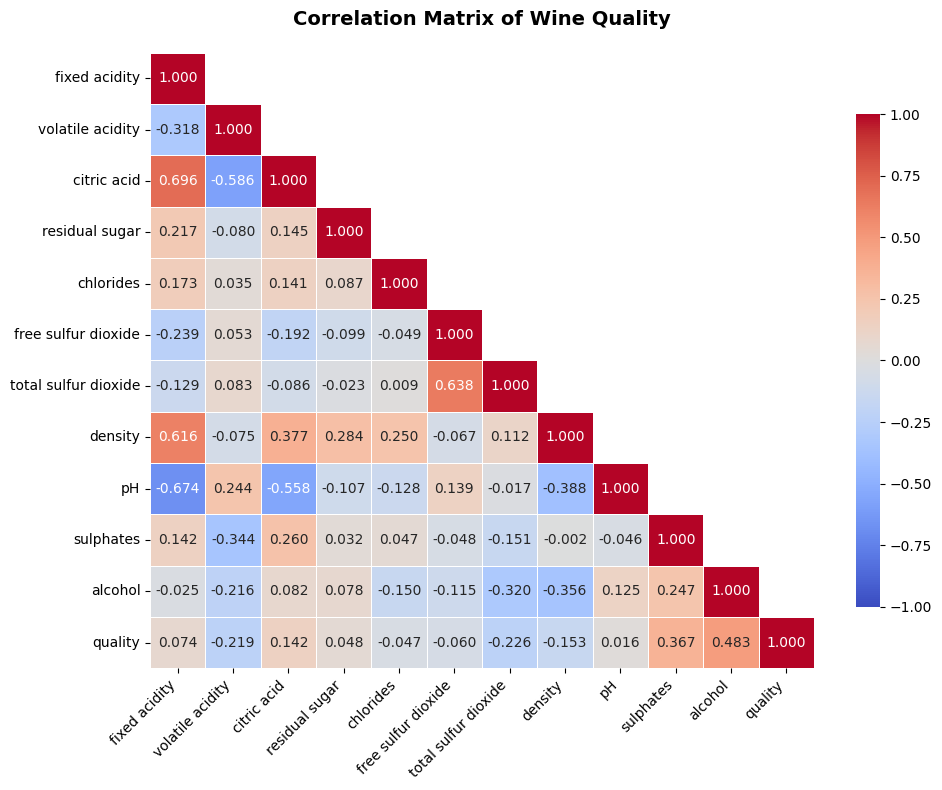

In [14]:
numerical_df = train_df.drop(columns=['Id'])

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8} 
)

plt.title('Correlation Matrix of Wine Quality', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [15]:
def remove_outliers_iqr(df):
    outlier = df.copy()
    cols = outlier.drop(columns=['Id', 'quality']).columns
    
    for col in cols:
        Q1 = outlier[col].quantile(0.25)
        Q3 = outlier[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        

        outlier = outlier[
            (outlier[col] >= lower_bound) & 
            (outlier[col] <= upper_bound)
        ]
        
    return outlier


In [16]:
clean_train_df = remove_outliers_iqr(train_df)

In [17]:
clean_train_df

,Id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,8.0,0.50,0.39,2.20,0.073,30.0,39.0,0.99572,3.33,0.77,12.1,6
1,1,9.3,0.30,0.73,2.30,0.092,30.0,67.0,0.99854,3.32,0.67,12.8,6
2,2,7.1,0.51,0.03,2.10,0.059,3.0,12.0,0.99660,3.52,0.73,11.3,7
3,3,8.1,0.87,0.22,2.60,0.084,11.0,65.0,0.99730,3.20,0.53,9.8,5
6,6,7.2,0.87,0.00,2.30,0.080,6.0,18.0,0.99552,3.34,0.60,11.3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051,2051,6.6,0.31,0.13,2.00,0.056,29.0,42.0,0.99388,3.52,0.87,12.0,7
2052,2052,9.7,0.59,0.21,1.80,0.079,27.0,65.0,0.99745,3.14,0.58,9.4,5
2053,2053,7.7,0.43,0.42,1.70,0.071,19.0,37.0,0.99258,3.32,0.77,12.5,8
2054,2054,9.1,0.50,0.00,1.75,0.058,5.0,13.0,0.99670,3.22,0.42,9.5,5


In [18]:
clean_train_df.shape

(1615, 13)

## 4. Feature Engineering (FE) & Data Preprocessing

In [19]:
clean_train_df['total_acidity'] = clean_train_df['fixed acidity'] + clean_train_df['volatile acidity']
clean_train_df['free_sulfur_ratio'] = clean_train_df['free sulfur dioxide'] / clean_train_df['total sulfur dioxide']
clean_train_df['acidity_to_pH_ratio'] = clean_train_df['total_acidity'] / clean_train_df['pH']

In [20]:
clean_train_df.shape

(1615, 16)

In [21]:
clean_train_df

,Id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity,free_sulfur_ratio,acidity_to_pH_ratio
0,0,8.0,0.50,0.39,2.20,0.073,30.0,39.0,0.99572,3.33,0.77,12.1,6,8.50,0.769231,2.552553
1,1,9.3,0.30,0.73,2.30,0.092,30.0,67.0,0.99854,3.32,0.67,12.8,6,9.60,0.447761,2.891566
2,2,7.1,0.51,0.03,2.10,0.059,3.0,12.0,0.99660,3.52,0.73,11.3,7,7.61,0.250000,2.161932
3,3,8.1,0.87,0.22,2.60,0.084,11.0,65.0,0.99730,3.20,0.53,9.8,5,8.97,0.169231,2.803125
6,6,7.2,0.87,0.00,2.30,0.080,6.0,18.0,0.99552,3.34,0.60,11.3,6,8.07,0.333333,2.416168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051,2051,6.6,0.31,0.13,2.00,0.056,29.0,42.0,0.99388,3.52,0.87,12.0,7,6.91,0.690476,1.963068
2052,2052,9.7,0.59,0.21,1.80,0.079,27.0,65.0,0.99745,3.14,0.58,9.4,5,10.29,0.415385,3.277070
2053,2053,7.7,0.43,0.42,1.70,0.071,19.0,37.0,0.99258,3.32,0.77,12.5,8,8.13,0.513514,2.448795
2054,2054,9.1,0.50,0.00,1.75,0.058,5.0,13.0,0.99670,3.22,0.42,9.5,5,9.60,0.384615,2.981366


In [22]:
test_df['total_acidity'] = test_df['fixed acidity'] + test_df['volatile acidity']
test_df['free_sulfur_ratio'] = test_df['free sulfur dioxide'] / test_df['total sulfur dioxide']
test_df['acidity_to_pH_ratio'] = test_df['total_acidity'] / test_df['pH']

In [23]:
test_df.shape

(1372, 15)

In [24]:
test_df

,Id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,total_acidity,free_sulfur_ratio,acidity_to_pH_ratio
0,2056,7.2,0.510,0.01,2.0,0.077,31.0,54.0,0.99748,3.39,0.59,9.8,7.710,0.574074,2.274336
1,2057,7.2,0.755,0.15,2.0,0.102,14.0,35.0,0.99586,3.33,0.68,10.0,7.955,0.400000,2.388889
2,2058,8.4,0.460,0.40,2.0,0.065,21.0,50.0,0.99774,3.08,0.65,9.5,8.860,0.420000,2.876623
3,2059,8.0,0.470,0.40,1.8,0.056,14.0,25.0,0.99480,3.30,0.65,11.7,8.470,0.560000,2.566667
4,2060,6.5,0.340,0.32,2.1,0.044,8.0,94.0,0.99356,3.23,0.48,12.8,6.840,0.085106,2.117647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1367,3423,8.8,0.745,0.18,2.7,0.084,41.0,115.0,0.99823,3.38,0.70,9.8,9.545,0.356522,2.823964
1368,3424,15.6,0.240,0.55,2.9,0.062,11.0,25.0,0.99724,2.99,0.77,10.1,15.840,0.440000,5.297659
1369,3425,7.3,0.760,0.00,2.2,0.095,6.0,19.0,0.99880,3.67,0.60,9.4,8.060,0.315789,2.196185
1370,3426,7.6,0.780,0.26,2.6,0.118,17.0,104.0,0.99616,3.30,0.53,9.9,8.380,0.163462,2.539394


## 5. Model Training, Optimization & Deployment Strategy

In [25]:
x = clean_train_df.drop(columns=['Id', 'quality'])
y = clean_train_df['quality']

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

def algo_test(x, y):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) 
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor(n_jobs=-1, random_state=42)                      
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, kn, ada, dt, xgb]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Extra Tree', 'Gradient Boosting', 'KNeighbors', 'AdaBoost', 
        'Decision Tree', 'XGBRegressor'
    ]
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    for algo, name in zip(algos, algo_names):
        print(f"Now training and evaluating: {name}...")
        
        model_fit = algo.fit(x_train_scaled, y_train)
        predictions = model_fit.predict(x_test_scaled)
        
        r_squared.append(r2_score(y_test, predictions))
        rmse.append(mean_squared_error(y_test, predictions) ** 0.5)
        mae.append(mean_absolute_error(y_test, predictions))
        
        print(f"{name} processing finished successfully.\n")
    
    rtable = result.assign(R_Squared=r_squared, RMSE=rmse, MAE=mae).sort_values('R_Squared', ascending=False)
    return rtable

In [27]:
comparison_table = algo_test(x, y)

Now training and evaluating: Linear...
Linear processing finished successfully.

Now training and evaluating: Ridge...
Ridge processing finished successfully.

Now training and evaluating: Lasso...
Lasso processing finished successfully.

Now training and evaluating: ElasticNet...
ElasticNet processing finished successfully.

Now training and evaluating: SGD...
SGD processing finished successfully.

Now training and evaluating: Extra Tree...
Extra Tree processing finished successfully.

Now training and evaluating: Gradient Boosting...
Gradient Boosting processing finished successfully.

Now training and evaluating: KNeighbors...
KNeighbors processing finished successfully.

Now training and evaluating: AdaBoost...
AdaBoost processing finished successfully.

Now training and evaluating: Decision Tree...
Decision Tree processing finished successfully.

Now training and evaluating: XGBRegressor...
XGBRegressor processing finished successfully.



In [28]:
comparison_table

,R_Squared,RMSE,MAE
Ridge,0.273003,0.732873,0.579432
Linear,0.272652,0.733050,0.579364
Gradient Boosting,0.255417,0.741685,0.576949
AdaBoost,0.200480,0.768559,0.586716
SGD,0.186746,0.775132,0.611924
KNeighbors,0.168593,0.783736,0.621672
XGBRegressor,0.143619,0.795420,0.617267
Lasso,-0.000066,0.859562,0.704265
ElasticNet,-0.000066,0.859562,0.704265
Decision Tree,-0.324217,0.989105,0.662539


In [29]:
x_train_full = clean_train_df.drop(columns=['Id', 'quality'])
y_train_full = clean_train_df['quality']
x_test_full = test_df.drop(columns=['Id'])

In [30]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_full)
x_test_scaled = scaler.transform(x_test_full)

In [31]:
final_ridge_model = Ridge()


In [32]:
final_ridge_model.fit(x_train_scaled, y_train_full)

Ridge()

In [33]:
raw_preds = final_ridge_model.predict(x_test_scaled)
final_preds = np.clip(raw_preds, 3, 8).round().astype(int)

In [43]:
train_raw_preds = final_ridge_model.predict(x_train_scaled)

def qwk_loss_func(coefficients):
    X_p = np.copy(train_raw_preds)
    for i, pred in enumerate(X_p):
        if pred < coefficients[0]: X_p[i] = 3
        elif pred < coefficients[1]: X_p[i] = 4
        elif pred < coefficients[2]: X_p[i] = 5
        elif pred < coefficients[3]: X_p[i] = 6
        elif pred < coefficients[4]: X_p[i] = 7
        else: X_p[i] = 8
    return -cohen_kappa_score(y_train_full, X_p, weights='quadratic')

initial_boundaries = [3.5, 4.5, 5.5, 6.5, 7.5]
optimization_result = minimize(qwk_loss_func, initial_boundaries, method='Nelder-Mead')
best_boundaries = optimization_result['x']

optimized_preds = np.copy(raw_preds)
for i, pred in enumerate(optimized_preds):
    if pred < best_boundaries[0]: optimized_preds[i] = 3
    elif pred < best_boundaries[1]: optimized_preds[i] = 4
    elif pred < best_boundaries[2]: optimized_preds[i] = 5
    elif pred < best_boundaries[3]: optimized_preds[i] = 6
    elif pred < best_boundaries[4]: optimized_preds[i] = 7
    else: optimized_preds[i] = 8
optimized_preds = np.clip(optimized_preds, 3, 8).astype(int)

train_final_preds = np.clip(train_raw_preds, 3, 8).round().astype(int)

kappa_old = cohen_kappa_score(y_train_full, train_final_preds, weights='quadratic')

In [44]:
kappa_old

np.float64(0.4964184110281866)

In [45]:
train_opt_preds = np.copy(train_raw_preds)

for i, pred in enumerate(train_opt_preds):
    if pred < best_boundaries[0]: train_opt_preds[i] = 3
    elif pred < best_boundaries[1]: train_opt_preds[i] = 4
    elif pred < best_boundaries[2]: train_opt_preds[i] = 5
    elif pred < best_boundaries[3]: train_opt_preds[i] = 6
    elif pred < best_boundaries[4]: train_opt_preds[i] = 7
    else: train_opt_preds[i] = 8
train_opt_preds = np.clip(train_opt_preds, 3, 8).astype(int)

kappa_new = cohen_kappa_score(y_train_full, train_opt_preds, weights='quadratic')

In [46]:
kappa_new

np.float64(0.5554645719711824)

In [38]:
submission_qwk = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': optimized_preds 
})
submission_qwk.to_csv('submission_qwk_final.csv', index=False)

In [39]:
joblib.dump(final_ridge_model, 'ridge_wine_model.joblib')

joblib.dump(scaler, 'minmax_scaler.joblib')

['minmax_scaler.joblib']

In [40]:
with open('ridge_wine_model.pkl', 'wb') as model_file:
    pickle.dump(final_ridge_model, model_file)

with open('minmax_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)